                                                    SVM (SUPPORT VECTOR MACHINE) ALGORITHM PROJECT

                                            Heart Disease Prediction Using Support Vector Machine (SVM) Algorithm



                                                        STEP 1 DATA LOADING ND UNDERSTANDING

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Train Test Split
from sklearn.model_selection import train_test_split

# SVM Model
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Cross Validation
from sklearn.model_selection import cross_val_score

# Pipeline
from sklearn.pipeline import Pipeline

# Save Model
import joblib
df = pd.read_csv('/content/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [2]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.shape

(1025, 14)

In [5]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


                                                                    STEP 2 DATA CLEANING

In [7]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


                                                      STEP 3 EDA

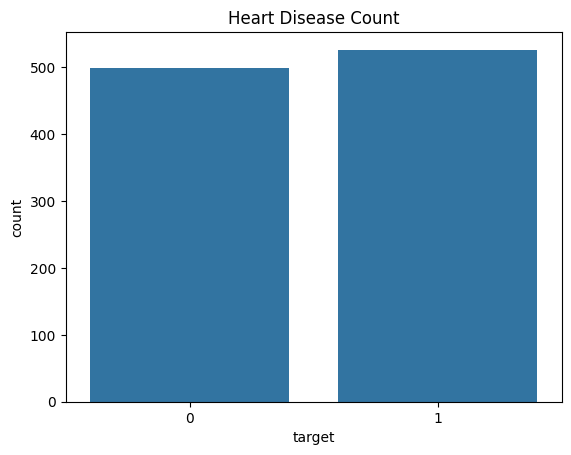

In [8]:
sns.countplot(x='target', data=df)

plt.title("Heart Disease Count")
plt.show()

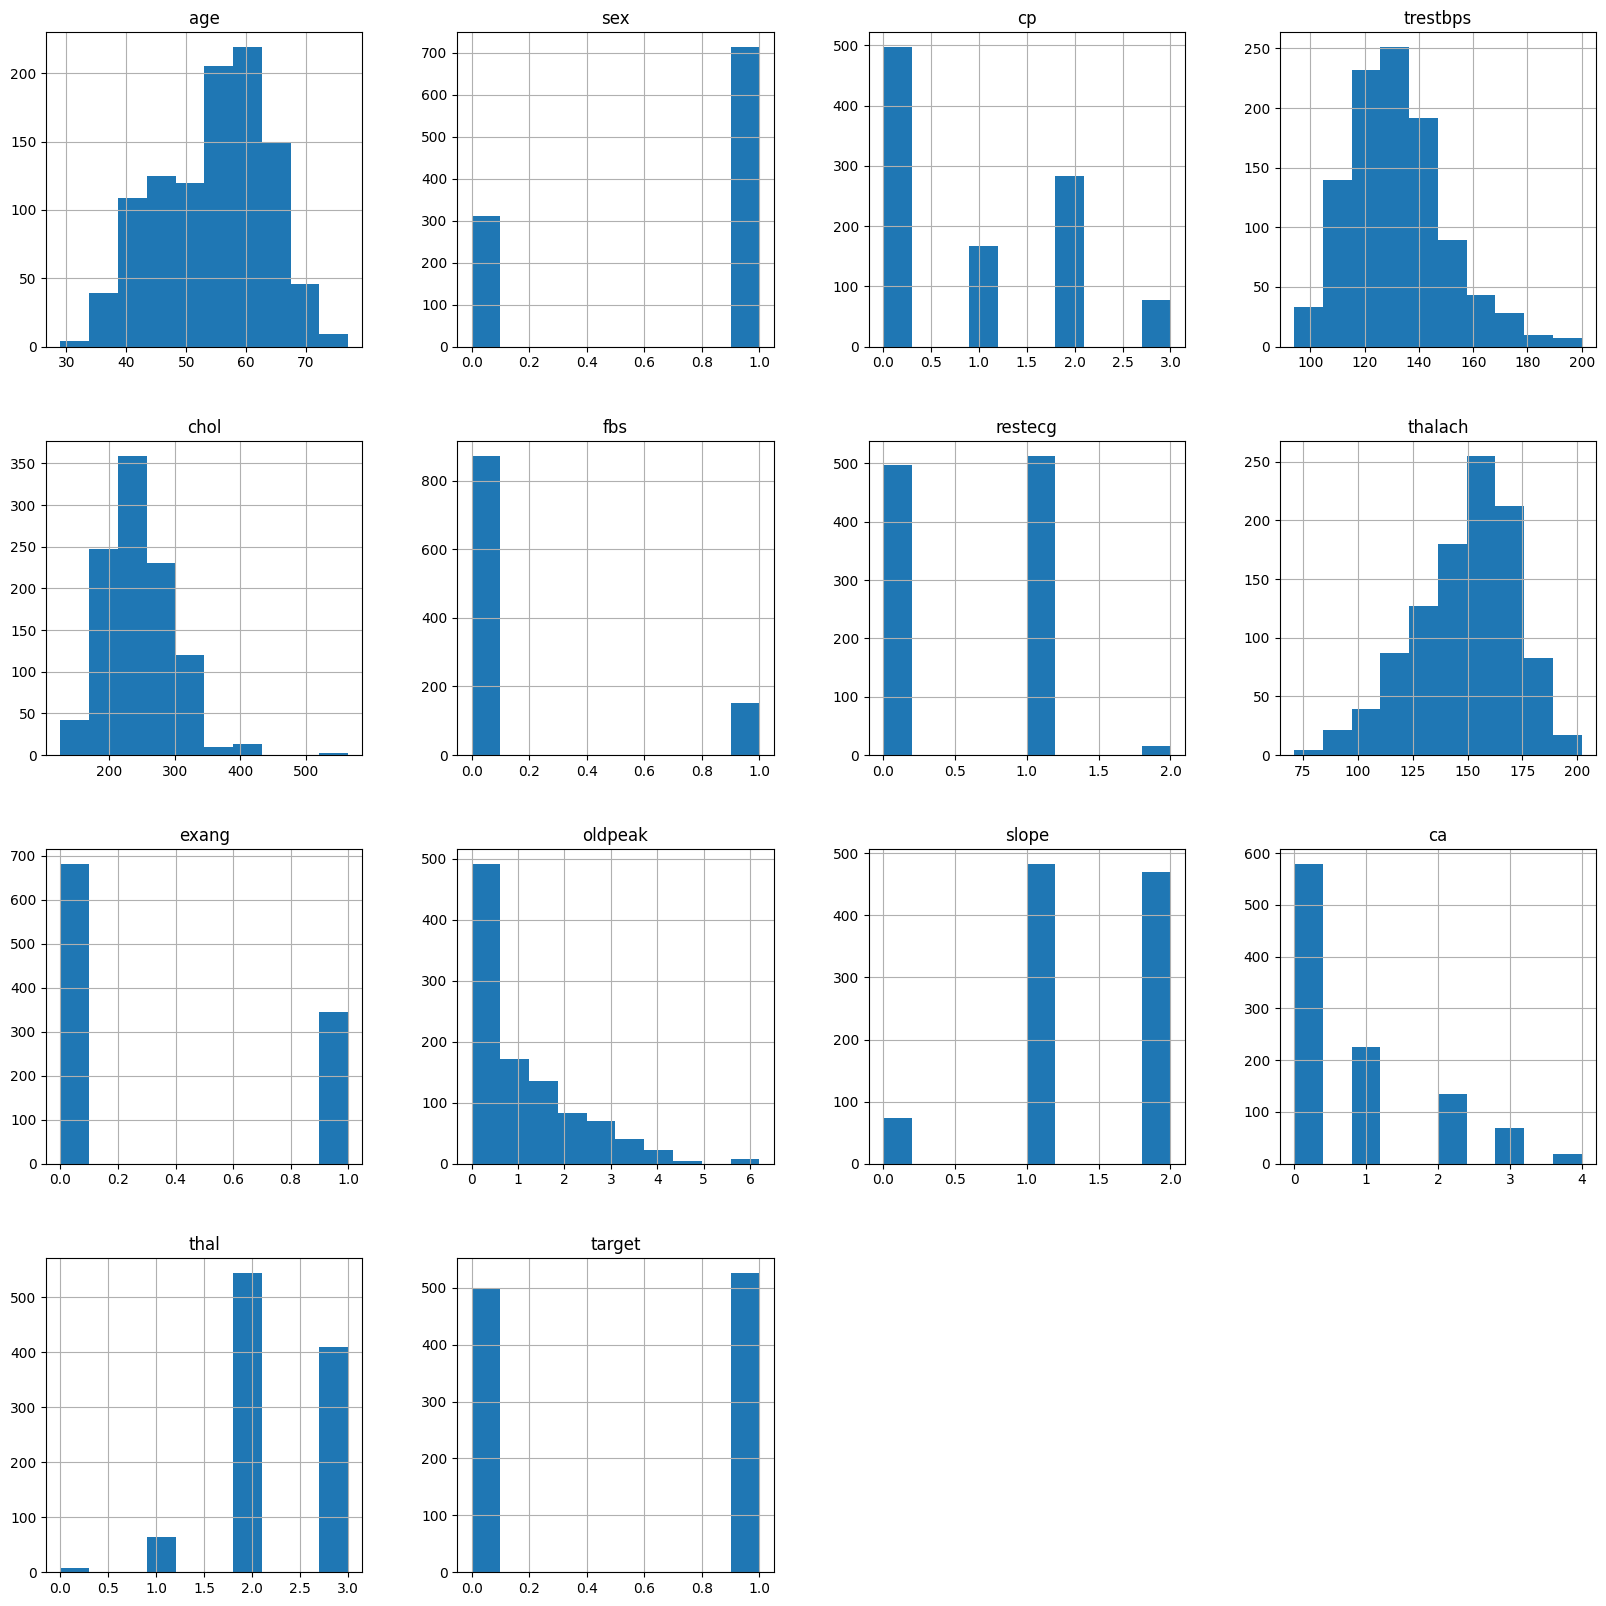

In [9]:
df.hist(figsize=(20,20))

plt.show()

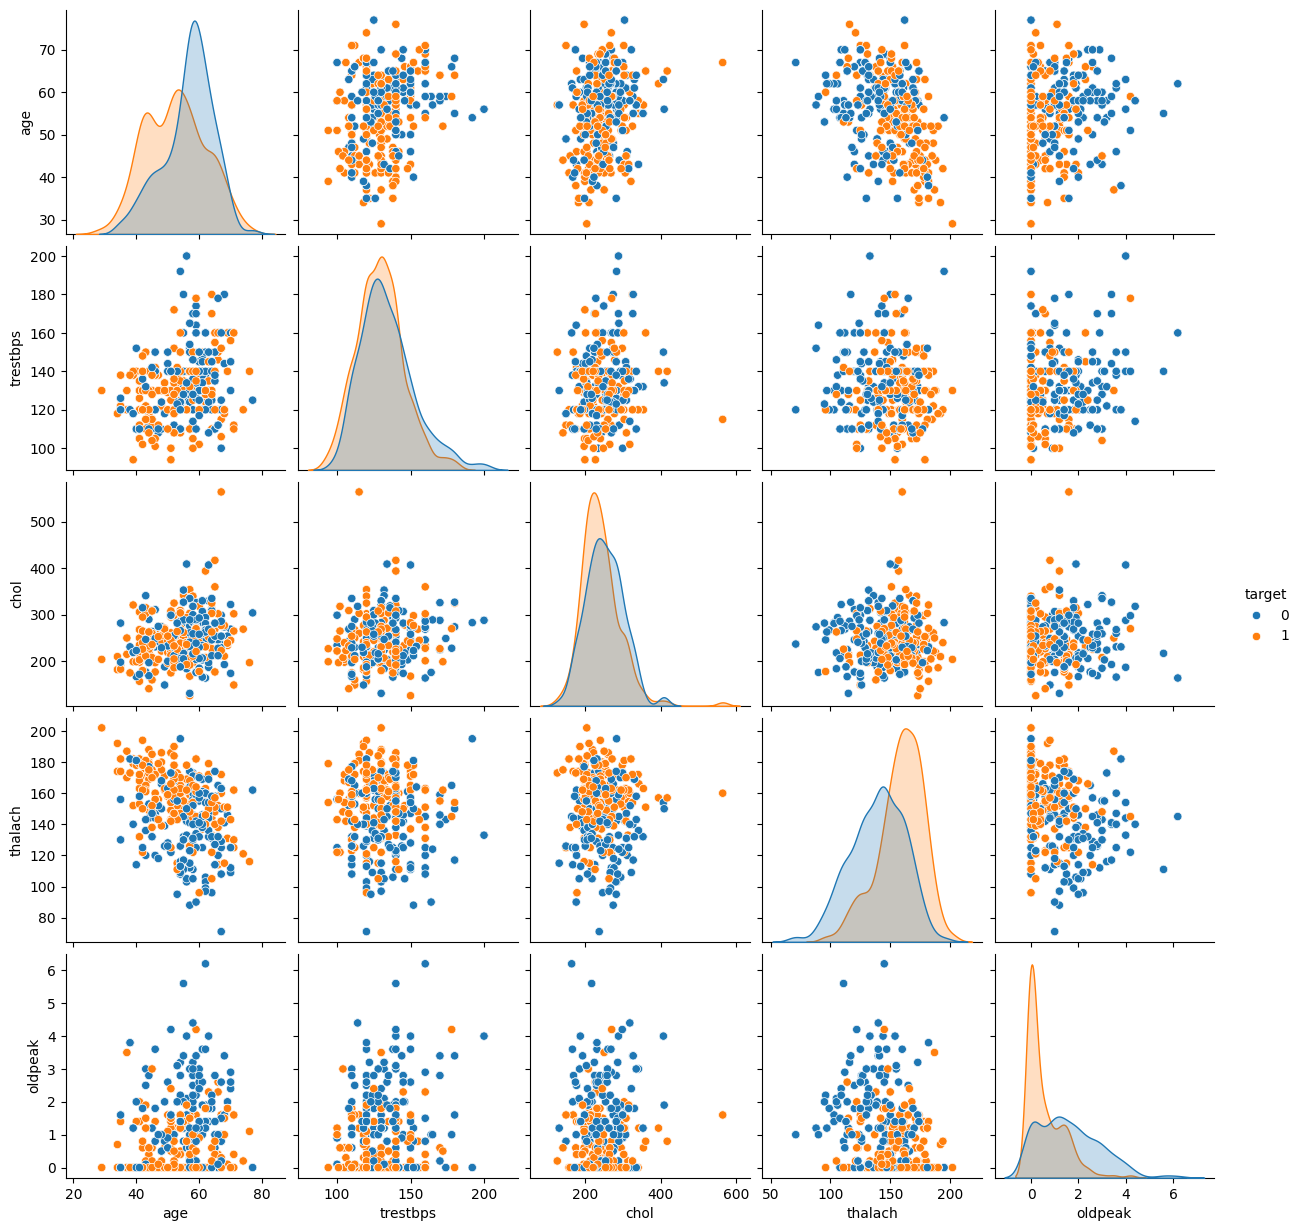

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pairplot for Bivariate Analysis
sns.pairplot(
    df[['age',
        'trestbps',
        'chol',
        'thalach',
        'oldpeak',
        'target']],
    hue='target'
)

plt.show()

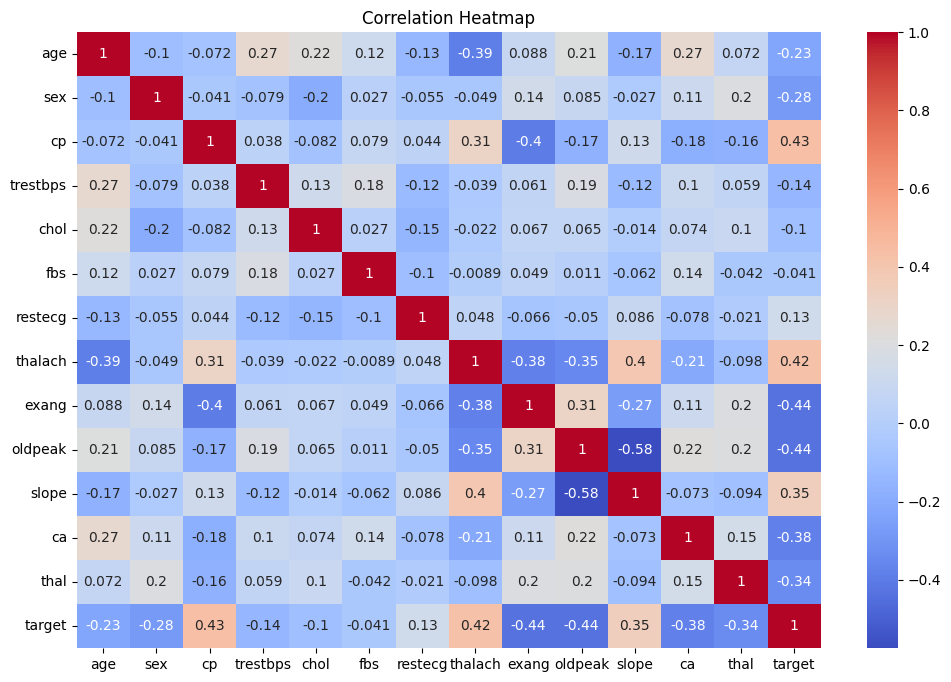

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

                                                          STEP 4 DATA PREPROCESSING

SEPERATING X AND Y

In [12]:
# Features and Target Variable

X = df.drop('target', axis=1)
y = df['target']

In [13]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [14]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [15]:
print(X.shape)

(1025, 13)


In [16]:
print(y.shape)

(1025,)


FEATURE SCAILING

In [17]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [18]:
print(X_scaled.shape)

(1025, 13)


                                                 STEP 5 TRAIN TEST SPLIT

In [19]:
from sklearn.model_selection import train_test_split

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Check shapes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(820, 13)
(205, 13)
(820,)
(205,)


                                                               STEP 6 MODEL SELECTON

In [20]:
from sklearn.svm import SVC

# Model Selection
svm_model = SVC()

In [21]:
from sklearn.svm import SVC

# Model Selection
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')

print(svm_model)

SVC()


In [22]:
# Display model parameters
svm_model.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

                                                    STEP 7  MODEL TRAINING

In [23]:
# Train the SVM Model
svm_model.fit(X_train, y_train)

print("SVM Model Training Completed")

SVM Model Training Completed


                                                          STEP 8 MODEL PREDICTION

In [24]:
y_pred = svm_model.predict(X_test)

                                                              STEP 9 MODEL EVALUATION

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import pandas as pd

# Training Accuracy
print("Training Accuracy:")
print(svm_model.score(X_train, y_train))

# Prediction
y_pred = svm_model.predict(X_test)

# First 10 Predicted Values
print("\nFirst 10 Predicted Values:")
print(y_pred[:10])

# Actual vs Predicted Comparison
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("\nActual vs Predicted:")
print(comparison.head(10))

# Accuracy Score
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Accuracy:
0.9548780487804878

First 10 Predicted Values:
[1 1 0 1 0 1 0 0 1 0]

Actual vs Predicted:
     Actual  Predicted
527       1          1
359       1          1
447       0          0
31        1          1
621       0          0
590       1          1
905       0          0
737       0          0
76        1          1
948       0          0

Accuracy Score:
0.8878048780487805

Confusion Matrix:
[[85 17]
 [ 6 97]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205



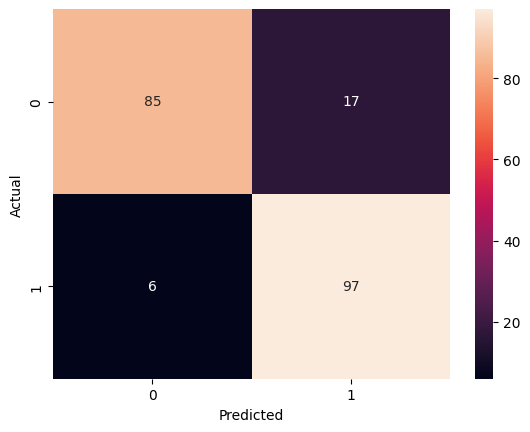

In [26]:
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.8508771929824561


In [28]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.941747572815534


In [29]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.8940092165898618


                                                            STEP 10 HYPER TUNING

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Hyperparameter Tuning
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

# Train GridSearchCV
grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", grid.best_params_)

# Best Cross Validation Accuracy
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.9658536585365853


BEST MODEL SELCTION

In [31]:
best_model = grid.best_estimator_

PREDICTION USING MODEL

In [32]:
y_pred_best = best_model.predict(X_test)

ACCURACY OF BEST MODEL

In [33]:
from sklearn.metrics import accuracy_score

print("Test Accuracy:")
print(accuracy_score(y_test, y_pred_best))

Test Accuracy:
0.975609756097561


CONFUSION MATRIX

In [34]:
from sklearn.metrics import confusion_matrix

cm_best = confusion_matrix(y_test, y_pred_best)

print(cm_best)

[[100   2]
 [  3 100]]


CLASSIFICATION MODEL

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       102
           1       0.98      0.97      0.98       103

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205



After hyperparameter tuning using GridSearchCV, the SVM model achieved excellent classification performance with approximately 98% accuracy, precision, recall, and F1-score. This indicates that the optimized model performed very effectively on the heart disease dataset.

                                                            STEP 11 CROSS VALADTION

Cross-validation was used to evaluate the consistency and generalization performance of the SVM model using 5-fold validation.

In [36]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X_scaled,
    y,
    cv=5
)

print(scores)

print("Mean Accuracy:", scores.mean())

[0.96585366 0.96097561 0.97560976 0.96585366 0.97560976]
Mean Accuracy: 0.968780487804878


The optimized SVM model achieved an average cross-validation accuracy of approximately 96.9%, indicating strong consistency and good generalization performance across different subsets of the dataset.

                                                      STEP 12 PIPELINE BUILDING

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Pipeline Building
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale'))
])

# Train Pipeline
pipeline.fit(X_train, y_train)

# Prediction
y_pred_pipeline = pipeline.predict(X_test)

# Pipeline Accuracy
print("Pipeline Accuracy:")
print(accuracy_score(y_test, y_pred_pipeline))

Pipeline Accuracy:
0.975609756097561


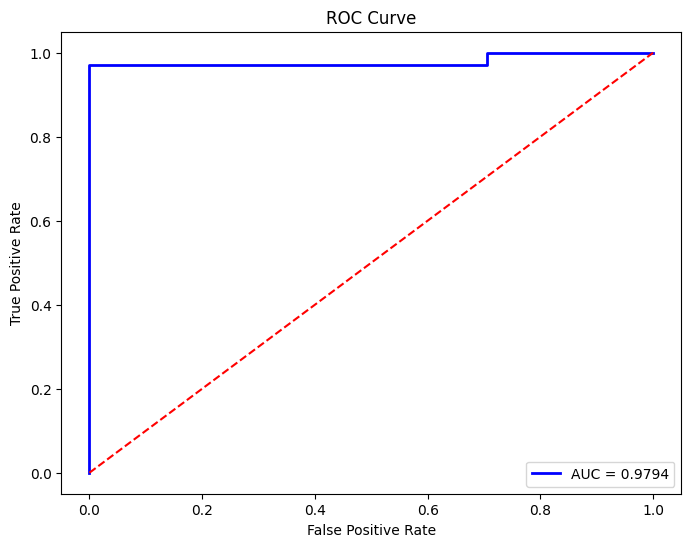

AUC Score: 0.9794


In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

svm_roc = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm_roc.fit(X_train, y_train)
y_prob = svm_roc.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

Final Conclusion

SVM Heart Disease Prediction Project

This project successfully implemented a Support Vector Machine (SVM) algorithm to predict heart disease using the Heart Disease dataset containing 1025 samples and 14 features.

Key Findings:

The data was clean with no missing values. After exploratory data analysis, feature scaling was applied using StandardScaler, and an 80/20 train-test split was used for model evaluation.

The initial SVM model with RBF kernel achieved a test accuracy of 88.78%. After hyperparameter tuning using GridSearchCV with best parameters (C=10, kernel='rbf', gamma='scale'), the model performance improved significantly to 97.56% accuracy.

Final Model Performance

Test Accuracy 97.56%

AUC Score 0.97

Precision 97-98%

Recall 97-98%

F1 Score 98%

Cross-Validation Mean 96.87%


Summary:

The optimized SVM model demonstrated excellent classification performance with consistent results across cross-validation folds, indicating strong generalization ability. The high AUC score of 0.97 confirms that the model effectively distinguishes between patients with and without heart disease.
This project proves that SVM with proper hyperparameter tuning is a highly effective algorithm for medical diagnosis tasks.